In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [4]:
logs=pd.read_csv('../data/cleaned_logs.csv')
metrics=pd.read_csv('../data/cleaned_metrics.csv')

In [5]:

metrics.head()

,id,timestamp,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count,hour,minute,...,disk_percent_min_30,network_sent_min_5,network_sent_min_10,network_sent_min_30,network_recv_min_5,network_recv_min_10,network_recv_min_30,process_count_min_5,process_count_min_10,process_count_min_30
0,128,2026-07-29 20:43:53.101717,13.8,88.9,85.6,264334942,1870188592,297,20,43,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
1,129,2026-07-29 20:43:56.120057,13.0,89.6,85.6,264342896,1870197527,297,20,43,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
2,130,2026-07-29 20:43:59.193420,21.0,89.2,85.6,264343634,1870198100,297,20,43,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
3,131,2026-07-29 20:44:02.212411,27.0,89.7,85.6,264371411,1870205197,297,20,44,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
4,132,2026-07-29 20:44:05.226557,22.9,90.2,85.6,264385470,1870207581,298,20,44,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0


In [6]:
logs.head()

,id,timestamp,level,message,uuid,logger_name,raw_log,cluster_id,template,created_at,...,date,weekday,message_length,contains_number,cluster_freq,minute,logs_per_minute,word_count,contains_ip,template_length
0,1,2026-07-29 20:53:34.994,WARNING,User 4003 logged in,512471f5-f355-496e-88ad-9db965dc5093,60 root,"[2026-07-29 20:53:34,994] 60 root - WARNING - ...",1,User 4003 logged in,2026-07-29 15:23:46,...,2026-07-29,Wednesday,19,1,NaN,2026-07-29 20:53:00,12,4,0,19
1,2,2026-07-29 20:53:37.004,WARNING,Worker 2 restarted,504b5c6e-d177-4b8a-afca-a4886218c3aa,60 root,"[2026-07-29 20:53:37,004] 60 root - WARNING - ...",2,Worker 2 restarted,2026-07-29 15:23:46,...,2026-07-29,Wednesday,18,1,1597.0,2026-07-29 20:53:00,12,3,0,18
2,3,2026-07-29 20:53:39.005,INFO,Payment for Order 54535 failed,7e9f8990-8bdf-4f16-b2a1-eaebd4385ad4,60 root,"[2026-07-29 20:53:39,005] 60 root - INFO - Pay...",3,Payment for Order 54535 failed,2026-07-29 15:23:46,...,2026-07-29,Wednesday,30,1,990.0,2026-07-29 20:53:00,12,5,0,30
3,4,2026-07-29 20:53:41.006,WARNING,Service auth restarted after 2 crashes,2aa3424f-a6de-44f9-acb1-bc5710abc4a2,60 root,"[2026-07-29 20:53:41,006] 60 root - WARNING - ...",4,Service auth restarted after 2 crashes,2026-07-29 15:23:46,...,2026-07-29,Wednesday,38,1,1762.0,2026-07-29 20:53:00,12,6,0,38
4,5,2026-07-29 20:53:43.007,ERROR,Connection from 192.168.1.232 accepted,23ae7c8f-4527-468a-87a8-99ad84595a97,60 root,"[2026-07-29 20:53:43,007] 60 root - ERROR - Co...",5,Connection from 192.168.1.232 accepted,2026-07-29 15:23:46,...,2026-07-29,Wednesday,38,1,1595.0,2026-07-29 20:53:00,12,4,1,38


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [8]:
from sklearn.ensemble import IsolationForest


In [9]:
X=metrics.drop(['id','timestamp'], axis=1)

In [10]:
X

,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count,hour,minute,second,date,...,disk_percent_min_30,network_sent_min_5,network_sent_min_10,network_sent_min_30,network_recv_min_5,network_recv_min_10,network_recv_min_30,process_count_min_5,process_count_min_10,process_count_min_30
0,13.8,88.9,85.6,264334942,1870188592,297,20,43,53,2026-07-29,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
1,13.0,89.6,85.6,264342896,1870197527,297,20,43,56,2026-07-29,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
2,21.0,89.2,85.6,264343634,1870198100,297,20,43,59,2026-07-29,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
3,27.0,89.7,85.6,264371411,1870205197,297,20,44,2,2026-07-29,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
4,22.9,90.2,85.6,264385470,1870207581,298,20,44,5,2026-07-29,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16046,25.0,94.0,85.3,378466548,2445426233,312,16,36,11,2026-07-30,...,85.3,378453046.0,378430735.0,378392465.0,2.445425e+09,2.445421e+09,2.445414e+09,312.0,312.0,312.0
16047,7.5,93.2,85.3,378466548,2445426319,311,16,36,11,2026-07-30,...,85.3,378453046.0,378430789.0,378392832.0,2.445425e+09,2.445421e+09,2.445415e+09,311.0,311.0,311.0
16048,10.7,93.1,85.3,378466548,2445426319,311,16,36,11,2026-07-30,...,85.3,378466365.0,378452449.0,378392928.0,2.445425e+09,2.445421e+09,2.445415e+09,311.0,311.0,311.0
16049,18.2,93.1,85.3,378466548,2445426319,311,16,36,12,2026-07-30,...,85.3,378466548.0,378452865.0,378393153.0,2.445426e+09,2.445424e+09,2.445415e+09,311.0,311.0,311.0


In [11]:
X.columns.unique()


Index(['cpu_percent', 'memory_percent', 'disk_percent', 'network_sent',
       'network_recv', 'process_count', 'hour', 'minute', 'second', 'date',
       'weekday', 'cpu_diff', 'memory_diff', 'disk_diff', 'network_sent_diff',
       'network_recv_diff', 'process_count_diff', 'network_sent_rate',
       'network_recv_rate', 'network_total_rate', 'time_diff',
       'cpu_percent_mean_5', 'cpu_percent_mean_10', 'cpu_percent_mean_30',
       'memory_percent_mean_5', 'memory_percent_mean_10',
       'memory_percent_mean_30', 'disk_percent_mean_5', 'disk_percent_mean_10',
       'disk_percent_mean_30', 'network_sent_mean_5', 'network_sent_mean_10',
       'network_sent_mean_30', 'network_recv_mean_5', 'network_recv_mean_10',
       'network_recv_mean_30', 'process_count_mean_5', 'process_count_mean_10',
       'process_count_mean_30', 'cpu_percent_std_5', 'cpu_percent_std_10',
       'cpu_percent_std_30', 'memory_percent_std_5', 'memory_percent_std_10',
       'memory_percent_std_30', 'disk

In [12]:
# Make sure all model features are numeric before scaling
if 'date' in X.columns:
    X['date'] = pd.to_datetime(X['date'], errors='coerce').astype('int64') // 10**9

# Coerce any remaining non-numeric columns to numeric where possible
for col in X.select_dtypes(include=['object']).columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X = X.fillna(0)

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
X_scaled

array([[-0.17680715, -0.25415354,  1.00799915, ..., -2.82115083,
        -2.8226264 , -2.84039707],
       [-0.23835814, -0.05942393,  1.00799915, ..., -2.82115083,
        -2.8226264 , -2.84039707],
       [ 0.37715177, -0.17069799,  1.00799915, ..., -2.82115083,
        -2.8226264 , -2.84039707],
       ...,
       [-0.41531724,  0.91422415,  0.37024513, ...,  0.24100544,
         0.33576359,  0.55306876],
       [ 0.1617233 ,  0.91422415,  0.37024513, ...,  0.24100544,
         0.33576359,  0.55306876],
       [ 0.13864168,  0.91422415,  0.37024513, ...,  0.24100544,
         0.33576359,  0.55306876]], shape=(16051, 93))

In [15]:
model = IsolationForest(

)

In [16]:
model.fit(X_scaled)

,n_estimators,100
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,None
,verbose,0
,warm_start,False


In [17]:
predictions = model.predict(X_scaled)

In [18]:
predictions 

array([-1, -1, -1, ...,  1,  1,  1], shape=(16051,))

In [19]:
metrics['anomaly'] = predictions

In [20]:
metrics.head()

,id,timestamp,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count,hour,minute,...,network_sent_min_5,network_sent_min_10,network_sent_min_30,network_recv_min_5,network_recv_min_10,network_recv_min_30,process_count_min_5,process_count_min_10,process_count_min_30,anomaly
0,128,2026-07-29 20:43:53.101717,13.8,88.9,85.6,264334942,1870188592,297,20,43,...,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0,-1
1,129,2026-07-29 20:43:56.120057,13.0,89.6,85.6,264342896,1870197527,297,20,43,...,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0,-1
2,130,2026-07-29 20:43:59.193420,21.0,89.2,85.6,264343634,1870198100,297,20,43,...,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0,-1
3,131,2026-07-29 20:44:02.212411,27.0,89.7,85.6,264371411,1870205197,297,20,44,...,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0,-1
4,132,2026-07-29 20:44:05.226557,22.9,90.2,85.6,264385470,1870207581,298,20,44,...,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0,-1


In [21]:
metrics

,id,timestamp,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count,hour,minute,...,network_sent_min_5,network_sent_min_10,network_sent_min_30,network_recv_min_5,network_recv_min_10,network_recv_min_30,process_count_min_5,process_count_min_10,process_count_min_30,anomaly
0,128,2026-07-29 20:43:53.101717,13.8,88.9,85.6,264334942,1870188592,297,20,43,...,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0,-1
1,129,2026-07-29 20:43:56.120057,13.0,89.6,85.6,264342896,1870197527,297,20,43,...,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0,-1
2,130,2026-07-29 20:43:59.193420,21.0,89.2,85.6,264343634,1870198100,297,20,43,...,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0,-1
3,131,2026-07-29 20:44:02.212411,27.0,89.7,85.6,264371411,1870205197,297,20,44,...,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0,-1
4,132,2026-07-29 20:44:05.226557,22.9,90.2,85.6,264385470,1870207581,298,20,44,...,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16046,16174,2026-07-30 16:36:11.077762,25.0,94.0,85.3,378466548,2445426233,312,16,36,...,378453046.0,378430735.0,378392465.0,2.445425e+09,2.445421e+09,2.445414e+09,312.0,312.0,312.0,1
16047,16175,2026-07-30 16:36:11.403165,7.5,93.2,85.3,378466548,2445426319,311,16,36,...,378453046.0,378430789.0,378392832.0,2.445425e+09,2.445421e+09,2.445415e+09,311.0,311.0,311.0,1
16048,16176,2026-07-30 16:36:11.722569,10.7,93.1,85.3,378466548,2445426319,311,16,36,...,378466365.0,378452449.0,378392928.0,2.445425e+09,2.445421e+09,2.445415e+09,311.0,311.0,311.0,1
16049,16177,2026-07-30 16:36:12.048381,18.2,93.1,85.3,378466548,2445426319,311,16,36,...,378466548.0,378452865.0,378393153.0,2.445426e+09,2.445424e+09,2.445415e+09,311.0,311.0,311.0,1


In [22]:
metrics["anomaly"].value_counts()

anomaly
 1    13943
-1     2108
Name: count, dtype: int64

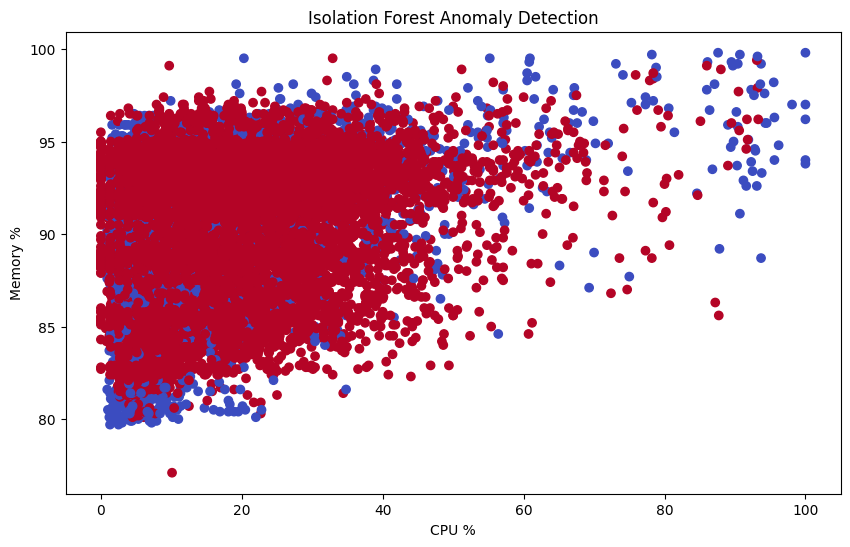

In [23]:
plt.figure(figsize=(10,6))

plt.scatter(
    metrics["cpu_percent"],
    metrics["memory_percent"],
    c=metrics["anomaly"],
    cmap="coolwarm"
)

plt.xlabel("CPU %")
plt.ylabel("Memory %")
plt.title("Isolation Forest Anomaly Detection")

plt.show()

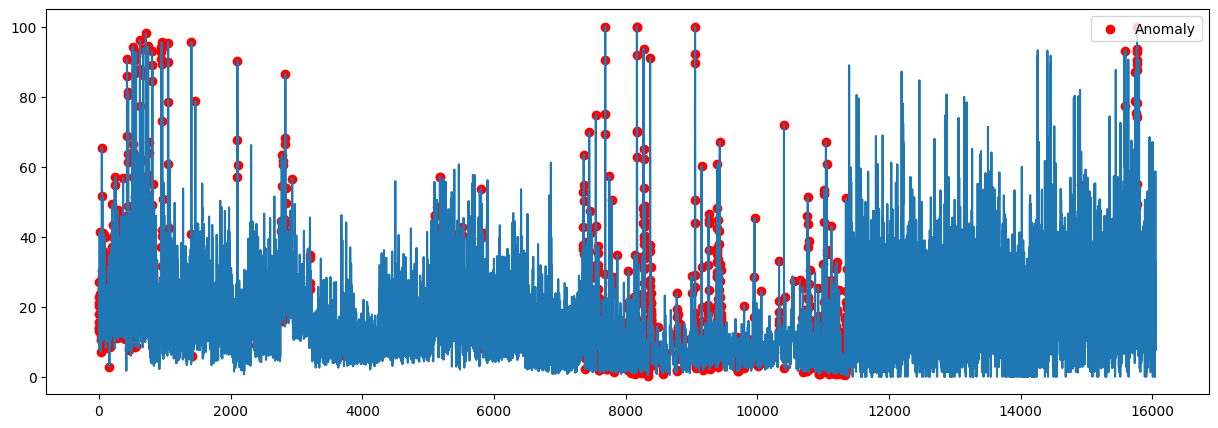

In [24]:
plt.figure(figsize=(15,5))

plt.plot(metrics["cpu_percent"])

plt.scatter(
    metrics.index[metrics["anomaly"] == -1],
    metrics.loc[metrics["anomaly"] == -1, "cpu_percent"],
    color="red",
    label="Anomaly"
)

plt.legend()

plt.show()

In [25]:
import time

In [26]:
start = time.perf_counter()

model.fit(X_scaled)

train_time = time.perf_counter() - start

print(f"Training Time: {train_time:.4f} seconds")

Training Time: 0.2602 seconds


In [27]:
start = time.perf_counter()

predictions = model.predict(X_scaled)

prediction_time = time.perf_counter() - start

print(f"Prediction Time: {prediction_time:.4f} seconds")

Prediction Time: 0.0573 seconds


In [28]:
metrics["prediction"] = predictions

In [29]:
anomalies = (metrics["prediction"] == -1).sum()

print("Total Anomalies :", anomalies)

Total Anomalies : 2270


In [30]:
anomaly_percent = (
    anomalies / len(metrics)
) * 100

print(f"Anomaly Percentage : {anomaly_percent:.2f}%")

Anomaly Percentage : 14.14%


In [31]:
print(metrics["prediction"].value_counts())

prediction
 1    13781
-1     2270
Name: count, dtype: int64


In [32]:
scores = model.decision_function(X_scaled)

metrics["anomaly_score"] = scores

metrics[["prediction","anomaly_score"]].head()

,prediction,anomaly_score
0,-1,-0.004375
1,-1,-0.009406
2,-1,-0.000102
3,-1,-0.004955
4,-1,-0.007658


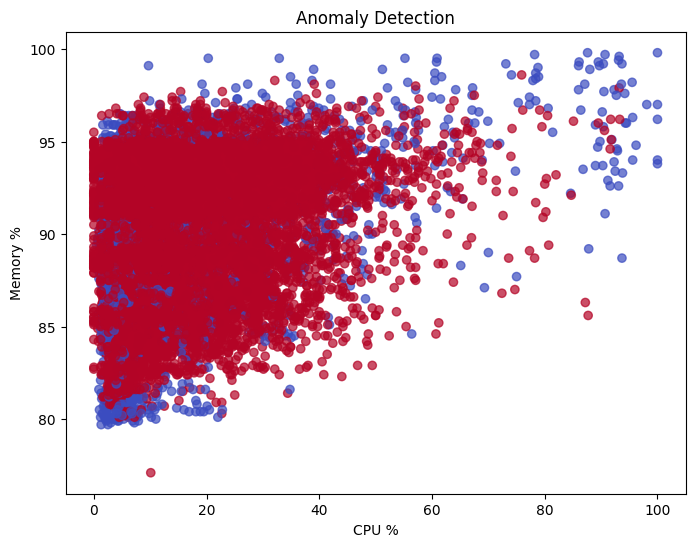

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    metrics["cpu_percent"],
    metrics["memory_percent"],
    c=metrics["prediction"],
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel("CPU %")
plt.ylabel("Memory %")
plt.title("Anomaly Detection")

plt.show()

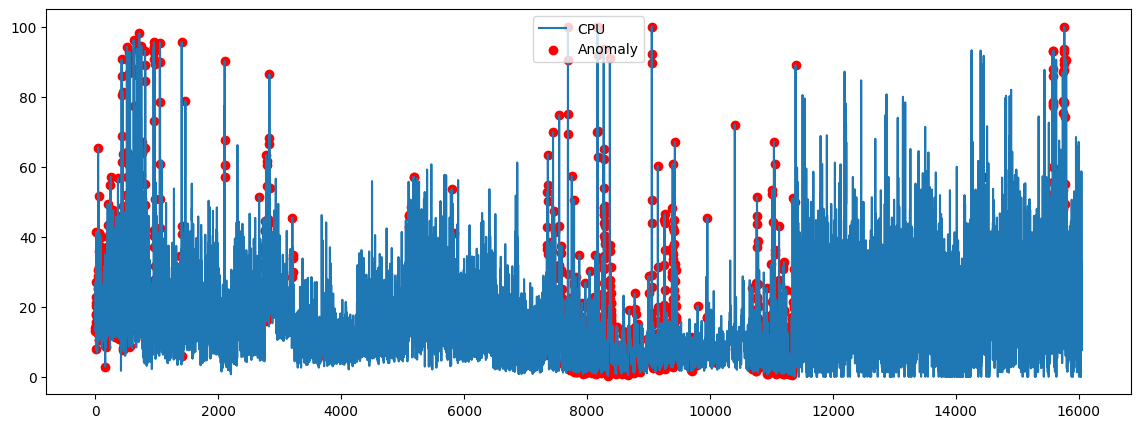

In [34]:
plt.figure(figsize=(14,5))

plt.plot(
    metrics["cpu_percent"],
    label="CPU"
)

plt.scatter(
    metrics.index[metrics["prediction"] == -1],
    metrics.loc[
        metrics["prediction"] == -1,
        "cpu_percent"
    ],
    color="red",
    label="Anomaly"
)

plt.legend()

plt.show()

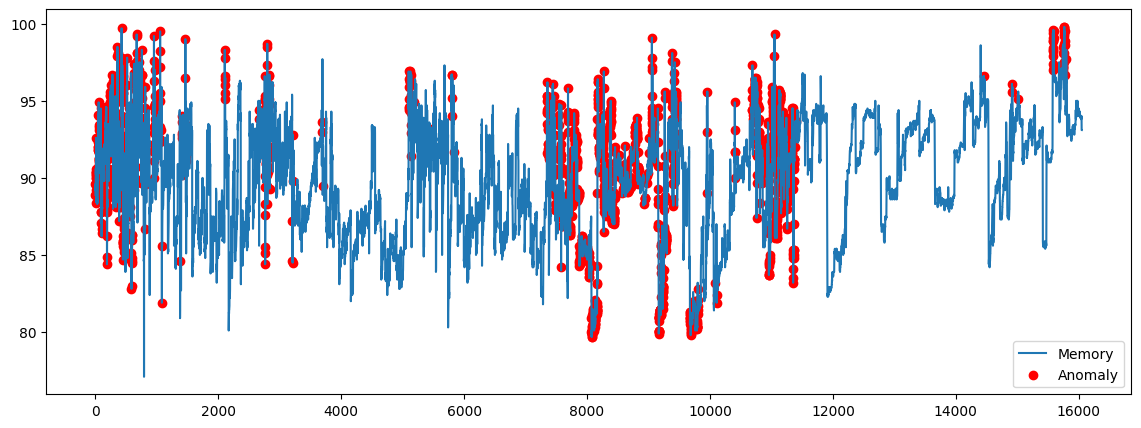

In [35]:
plt.figure(figsize=(14,5))

plt.plot(
    metrics["memory_percent"],
    label="Memory"
)

plt.scatter(
    metrics.index[metrics["prediction"] == -1],
    metrics.loc[
        metrics["prediction"] == -1,
        "memory_percent"
    ],
    color="red",
    label="Anomaly"
)

plt.legend()

plt.show()

In [36]:
results = pd.DataFrame({
    "Model": ["Isolation Forest"],
    "Training Time (s)": [train_time],
    "Prediction Time (s)": [prediction_time],
    "Anomalies": [anomalies],
    "Anomaly %": [anomaly_percent]
})

results

,Model,Training Time (s),Prediction Time (s),Anomalies,Anomaly %
0,Isolation Forest,0.260195,0.057272,2270,14.142421


In [37]:
import time
import numpy as np
import pandas as pd

def evaluate_model(model, X, model_name):
    """
    Train and evaluate an unsupervised anomaly detection model.

    Parameters
    ----------
    model : sklearn estimator
        Initialized anomaly detection model.
    X : ndarray or DataFrame
        Scaled feature matrix.
    model_name : str
        Name of the model.

    Returns
    -------
    result : dict
        Summary metrics.
    predictions : ndarray
        Predicted labels (1 = normal, -1 = anomaly).
    scores : ndarray or None
        Decision scores if supported.
    """

    # ---------------- Training ---------------- #
    start = time.perf_counter()

    model.fit(X)

    train_time = time.perf_counter() - start

    # ---------------- Prediction ---------------- #
    start = time.perf_counter()

    predictions = model.predict(X)

    prediction_time = time.perf_counter() - start

    # ---------------- Decision Scores ---------------- #
    try:
        scores = model.decision_function(X)
    except Exception:
        scores = None

    # ---------------- Metrics ---------------- #
    anomaly_count = np.sum(predictions == -1)

    anomaly_percentage = (
        anomaly_count / len(predictions)
    ) * 100

    result = {
        "Model": model_name,
        "Training Time (s)": round(train_time,4),
        "Prediction Time (s)": round(prediction_time,4),
        "Total Samples": len(predictions),
        "Anomalies": anomaly_count,
        "Normal": len(predictions)-anomaly_count,
        "Anomaly %": round(anomaly_percentage,2)
    }

    return result, predictions, scores

def evaluate_dbscan(model, X, model_name):
    """Evaluate DBSCAN using fit_predict because it does not expose predict()."""

    start = time.perf_counter()

    predictions = model.fit_predict(X)

    fit_time = time.perf_counter() - start

    anomaly_count = np.sum(predictions == -1)
    anomaly_percentage = (anomaly_count / len(predictions)) * 100

    result = {
        "Model": model_name,
        "Training Time (s)": round(fit_time, 4),
        "Prediction Time (s)": 0.0,
        "Total Samples": len(predictions),
        "Anomalies": anomaly_count,
        "Normal": len(predictions) - anomaly_count,
        "Anomaly %": round(anomaly_percentage, 2)
    }

    return result, predictions, None

In [38]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

result, pred, score = evaluate_model(
    iso,
    X_scaled,
    "Isolation Forest"
)

print(result)

{'Model': 'Isolation Forest', 'Training Time (s)': 0.3322, 'Prediction Time (s)': 0.0725, 'Total Samples': 16051, 'Anomalies': np.int64(321), 'Normal': np.int64(15730), 'Anomaly %': np.float64(2.0)}


In [39]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.covariance import EllipticEnvelope
models = {
    "Isolation Forest": IsolationForest(
        contamination=0.02,
        random_state=42
    ),
    "LOF": LocalOutlierFactor(
        contamination=0.02,
        n_neighbors=20,
        novelty=True
    ),
    "One-Class SVM": OneClassSVM(
        nu=0.02,
        kernel="rbf"
    ),
    "DBSCAN": DBSCAN(
        eps=0.5,
        min_samples=5
    ),

    "ELLIPTIC ENVELOPE": EllipticEnvelope(
        contamination=0.02,
        random_state=42
    )
}

results = []

for name, model in models.items():
    if name == "DBSCAN":
        res, pred, score = evaluate_dbscan(
            model,
            X_scaled,
            name
        )
    else:
        res, pred, score = evaluate_model(
            model,
            X_scaled,
            name
        )

    results.append(res)

    safe_name = name.replace(" ", "_").replace("-", "_")
    metrics[f"{safe_name}_prediction"] = pred

    if score is not None:
        metrics[f"{safe_name}_score"] = score

if "comparison_results" in globals() and not comparison_results.empty:
    comparison_results = pd.concat(
        [comparison_results, pd.DataFrame(results)],
        ignore_index=True
    )
else:
    comparison_results = pd.DataFrame(results)

comparison_results

c:\Users\Lenovo\anaconda3\envs\ai-platform\lib\site-packages\sklearn\covariance\_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


,Model,Training Time (s),Prediction Time (s),Total Samples,Anomalies,Normal,Anomaly %
0,Isolation Forest,0.2875,0.0565,16051,321,15730,2.00
1,LOF,11.3430,0.5139,16051,256,15795,1.59
2,One-Class SVM,0.8482,0.6139,16051,331,15720,2.06
3,DBSCAN,0.4772,0.0000,16051,16034,17,99.89
4,ELLIPTIC ENVELOPE,7.5969,0.0488,16051,321,15730,2.00


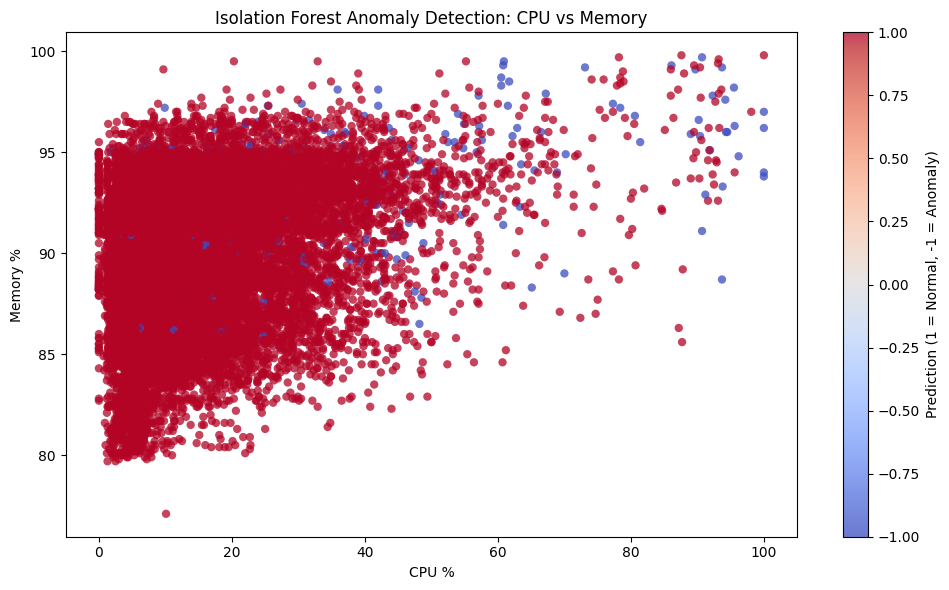

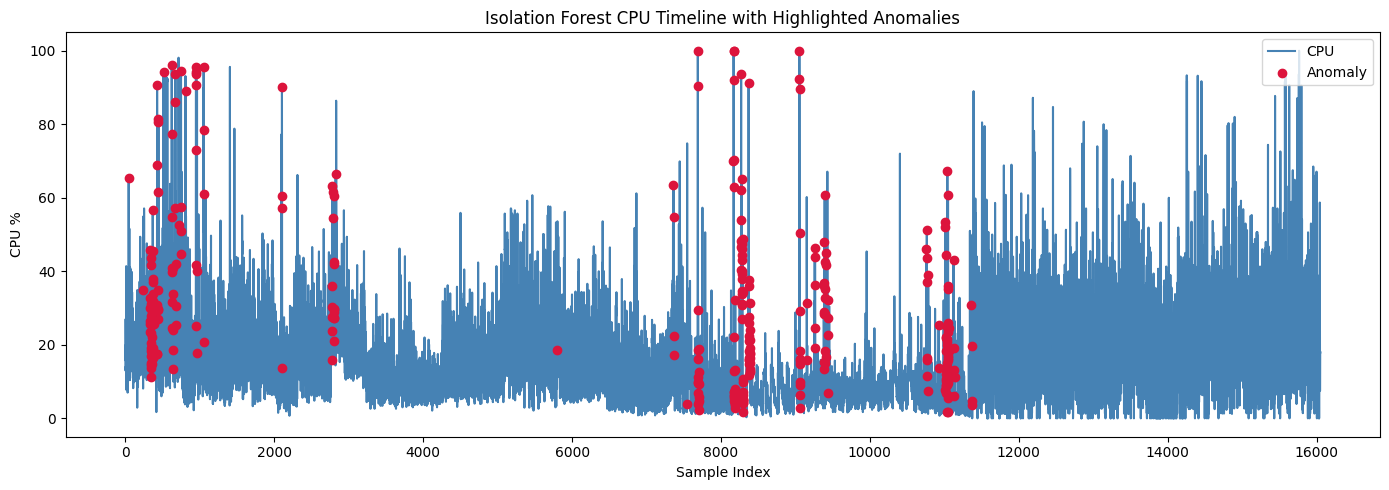

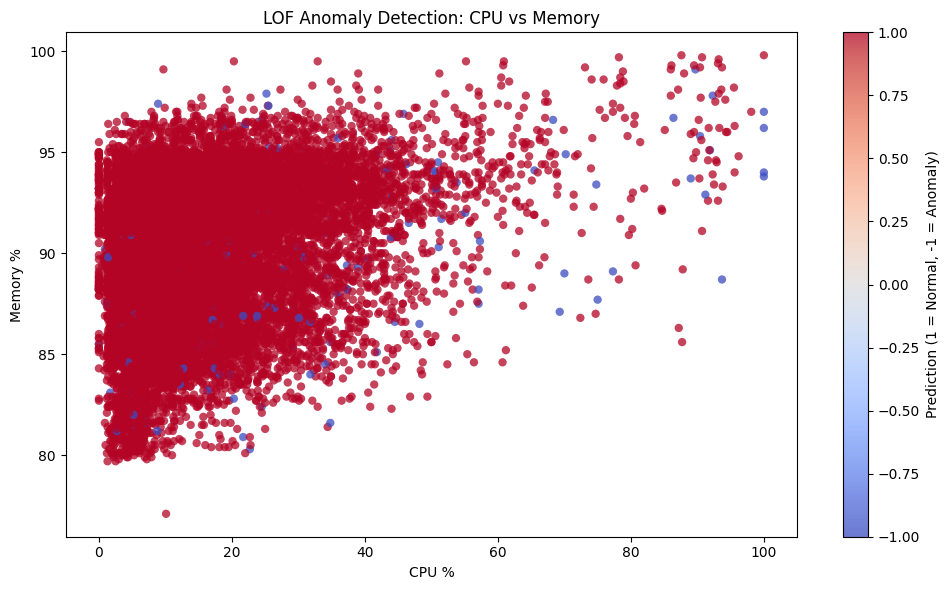

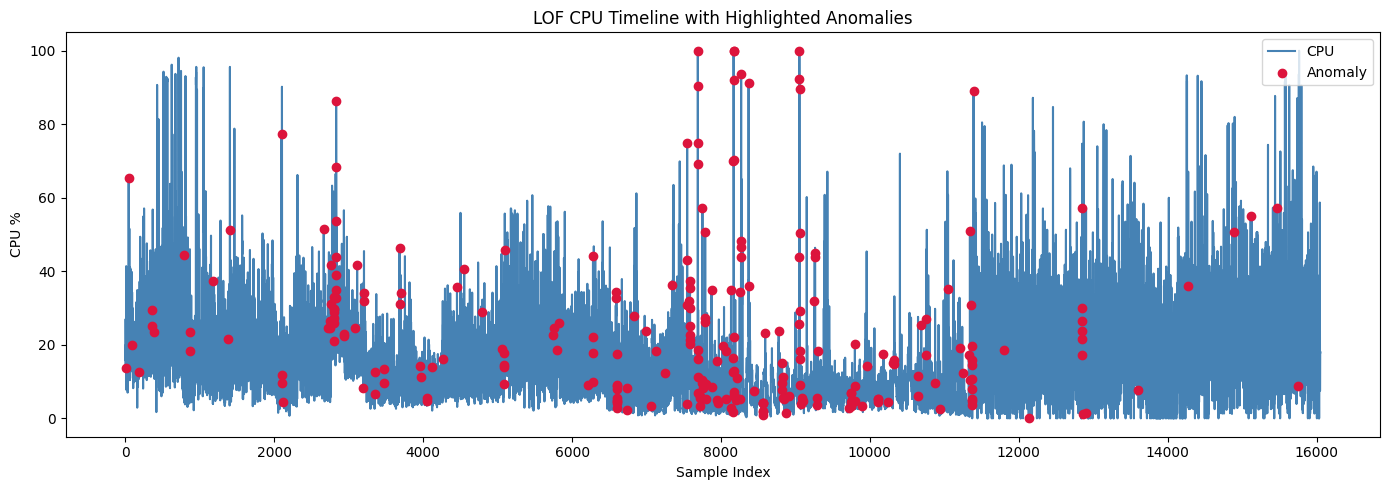

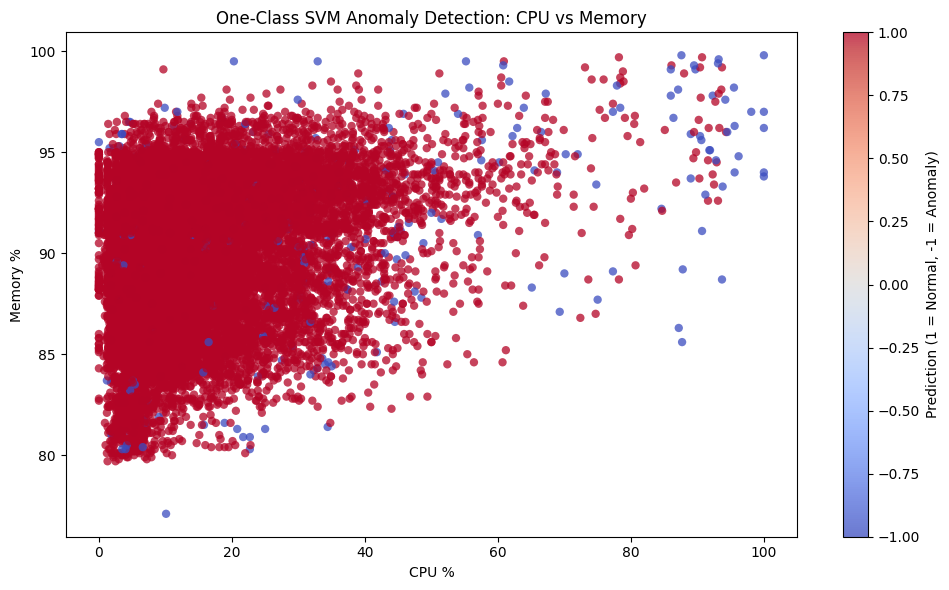

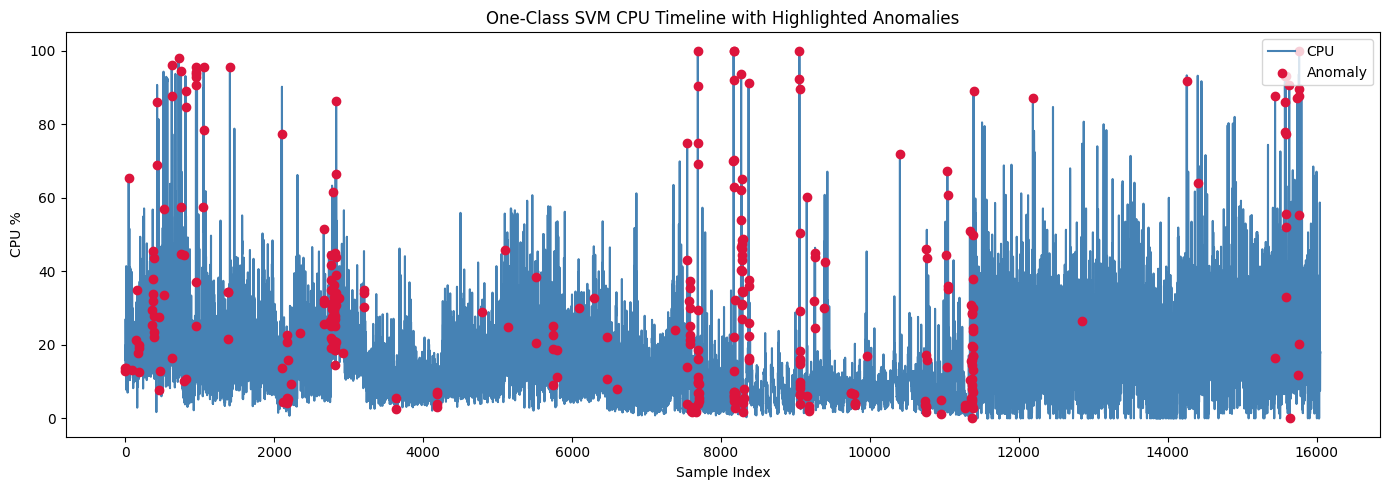

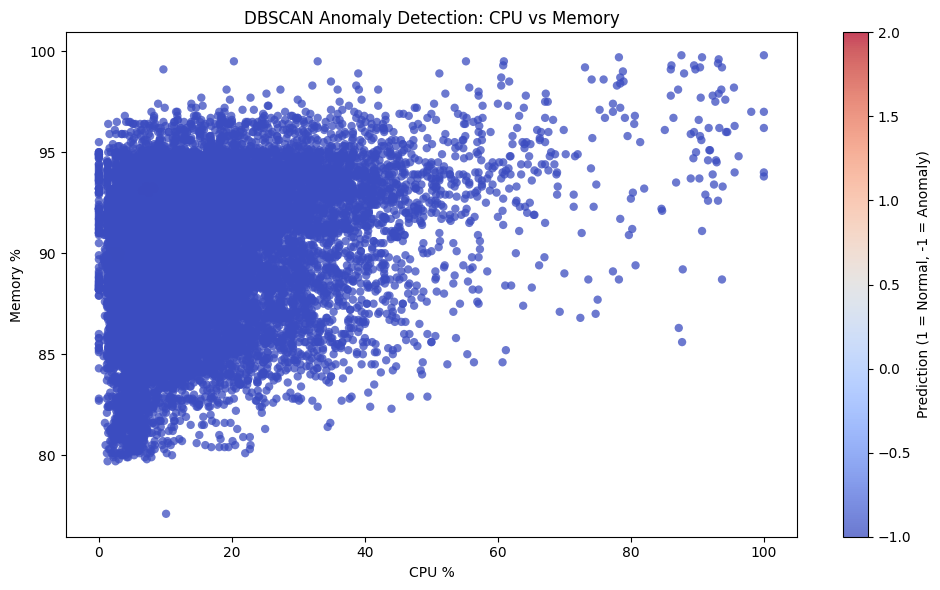

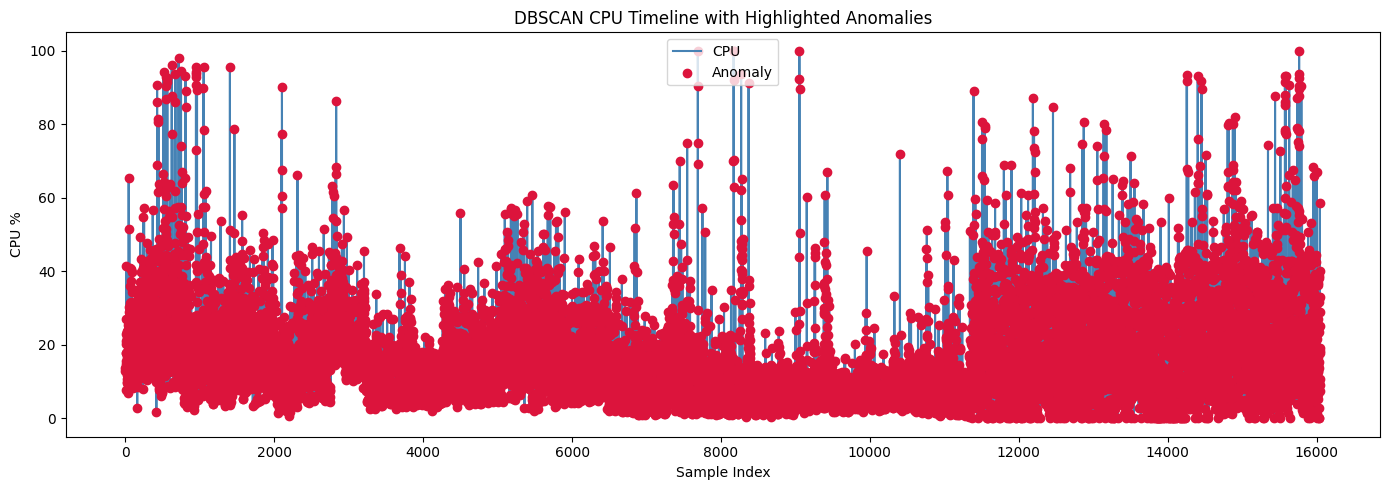

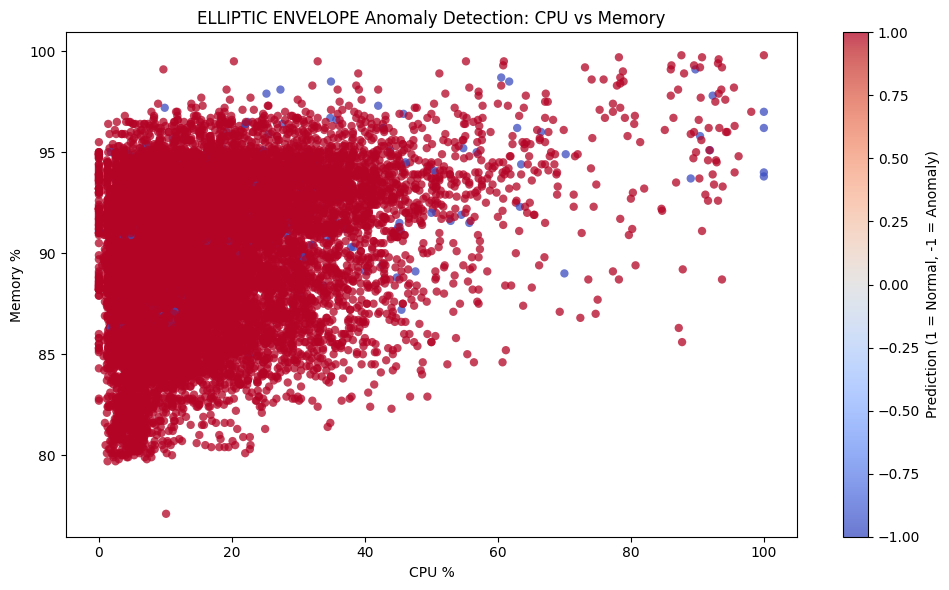

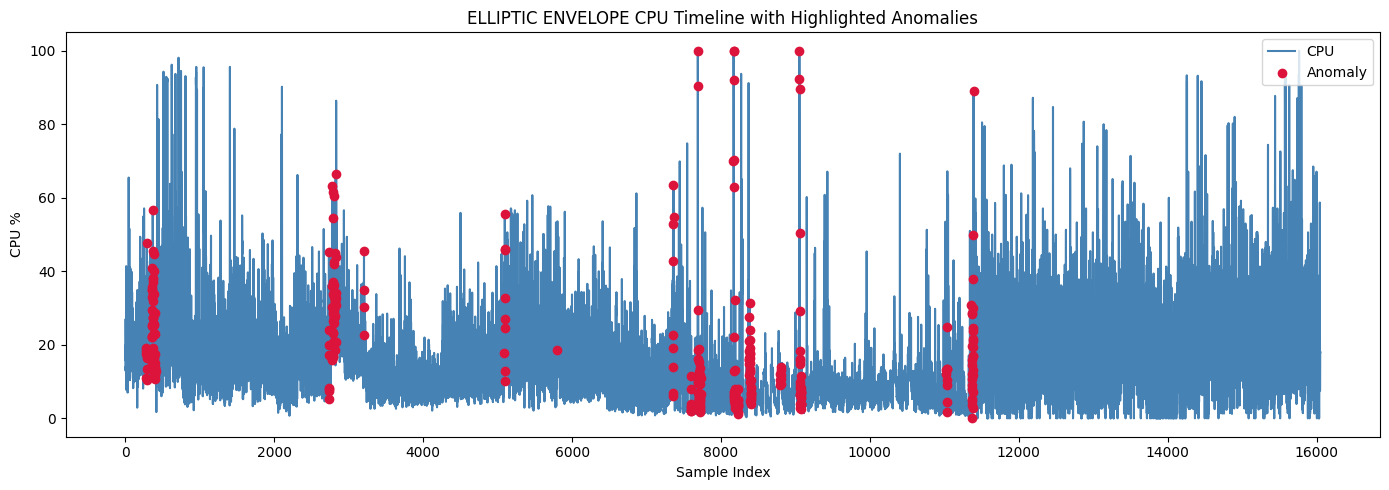

In [40]:
 
for name, model in models.items():
    safe_name = name.replace(" ", "_").replace("-", "_")
    prediction_column = f"{safe_name}_prediction"

    if prediction_column not in metrics.columns:
        continue

    plt.figure(figsize=(10, 6))
    plt.scatter(
        metrics["cpu_percent"],
        metrics["memory_percent"],
        c=metrics[prediction_column],
        cmap="coolwarm",
        alpha=0.75,
        edgecolors="none"
    )

    plt.xlabel("CPU %")
    plt.ylabel("Memory %")
    plt.title(f"{name} Anomaly Detection: CPU vs Memory")
    plt.colorbar(label="Prediction (1 = Normal, -1 = Anomaly)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(metrics["cpu_percent"], label="CPU", color="steelblue")

    anomaly_mask = metrics[prediction_column] == -1
    plt.scatter(
        metrics.index[anomaly_mask],
        metrics.loc[anomaly_mask, "cpu_percent"],
        color="crimson",
        label="Anomaly",
        zorder=3
    )

    plt.xlabel("Sample Index")
    plt.ylabel("CPU %")
    plt.title(f"{name} CPU Timeline with Highlighted Anomalies")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [41]:
from sklearn.decomposition import PCA

# Reduce to 2 dimensions
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(16051, 2)


In [42]:
metrics.head()

,id,timestamp,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count,hour,minute,...,anomaly_score,Isolation_Forest_prediction,Isolation_Forest_score,LOF_prediction,LOF_score,One_Class_SVM_prediction,One_Class_SVM_score,DBSCAN_prediction,ELLIPTIC_ENVELOPE_prediction,ELLIPTIC_ENVELOPE_score
0,128,2026-07-29 20:43:53.101717,13.8,88.9,85.6,264334942,1870188592,297,20,43,...,-0.004375,1,0.050560,1,0.117155,-1,-1.030682,-1,1,3.805301e+08
1,129,2026-07-29 20:43:56.120057,13.0,89.6,85.6,264342896,1870197527,297,20,43,...,-0.009406,1,0.054690,1,0.207758,-1,-0.457073,-1,1,3.805298e+08
2,130,2026-07-29 20:43:59.193420,21.0,89.2,85.6,264343634,1870198100,297,20,43,...,-0.000102,1,0.064046,1,0.321977,1,0.111037,-1,1,3.805300e+08
3,131,2026-07-29 20:44:02.212411,27.0,89.7,85.6,264371411,1870205197,297,20,44,...,-0.004955,1,0.068534,1,0.334465,1,0.252991,-1,1,3.805296e+08
4,132,2026-07-29 20:44:05.226557,22.9,90.2,85.6,264385470,1870207581,298,20,44,...,-0.007658,1,0.072259,1,0.354907,1,0.975869,-1,1,3.805292e+08


In [43]:

import pandas as pd

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Prediction"] = metrics["Isolation_Forest_prediction"]

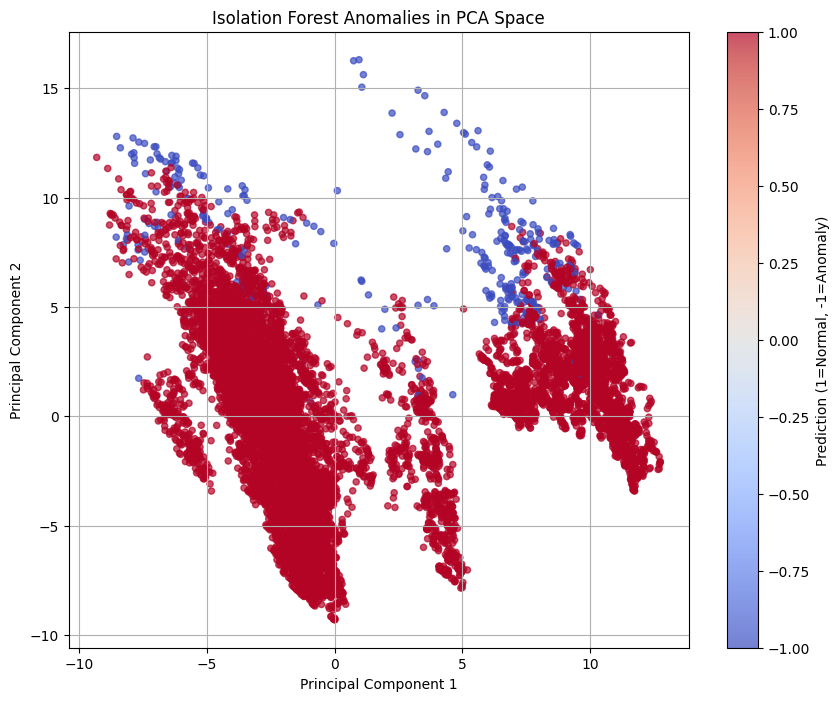

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Prediction"],
    cmap="coolwarm",
    s=20,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Isolation Forest Anomalies in PCA Space")

plt.colorbar(label="Prediction (1=Normal, -1=Anomaly)")
plt.grid(True)

plt.show()

In [45]:
print("Explained Variance Ratio")

for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")

Explained Variance Ratio
PC1: 0.2726
PC2: 0.1558


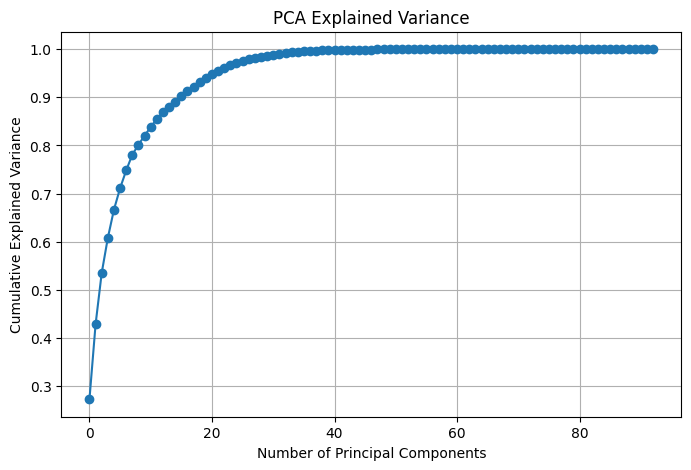

In [46]:
import numpy as np
from sklearn.decomposition import PCA

pca_full = PCA()

pca_full.fit(X_scaled)

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca_full.explained_variance_ratio_),
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)

plt.show()

### LOF notes

- `n_neighbors` controls the local neighborhood size used to estimate density. Smaller values make the model more sensitive to tiny local deviations; larger values smooth over noise.
- `contamination` sets the expected anomaly rate and helps calibrate the decision boundary.
- `novelty=True` enables production-style scoring on standardized feature vectors after fitting.
- LOF is preferred over Isolation Forest when anomalies are local-density based, especially when normal behavior forms clusters with different densities.

**Limitations**

- LOF is sensitive to the scale of the input features and the choice of `n_neighbors`.
- It can become expensive on larger datasets because it relies on nearest-neighbor calculations.
- It is generally weaker on very high-dimensional or sparse data where distance-based neighborhoods lose meaning.

In [48]:
import joblib
from pathlib import Path

SAVE_DIR = Path("models/metrics")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Save trained models
# -----------------------------

joblib.dump(models["Isolation Forest"], SAVE_DIR / "isolation_forest.pkl")
joblib.dump(models["One-Class SVM"], SAVE_DIR / "one_class_svm.pkl")
joblib.dump(models["LOF"], SAVE_DIR / "local_outlier_factor.pkl")
joblib.dump(models["ELLIPTIC ENVELOPE"], SAVE_DIR / "elliptic_envelope.pkl")

# DBSCAN (optional)
joblib.dump(models["DBSCAN"], SAVE_DIR / "dbscan.pkl")

# -----------------------------
# Save preprocessing objects
# -----------------------------

joblib.dump(scaler, SAVE_DIR / "scaler.pkl")
joblib.dump(pca, SAVE_DIR / "pca.pkl")

print("✅ Metrics models saved successfully!")

✅ Metrics models saved successfully!
